<a href="https://colab.research.google.com/github/willow788/one-model-a-week-keeps-the-fomo-away/blob/main/mnist1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# learn = tf.contrib.learn # tf.contrib has been deprecated and removed in TensorFlow 2.x
# tf.logging.set_verbosity(tf.logging.ERROR) # tf.logging has been removed in TensorFlow 2.x

In [6]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

data = x_train
labels = np.asarray(y_train, dtype=np.int32)

test_data = x_test
test_labels = np.asarray(y_test, dtype=np.int32)



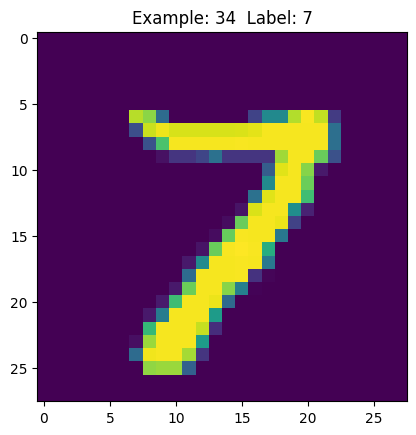

In [8]:
#making a dataset
max_samples = 1000
data  = data[:max_samples]
labels = labels[:max_samples]

#displaying a sample
def display(i):
  image = test_data[i]
  plt.title('Example: %d  Label: %d' % (i, test_labels[i]))
  plt.imshow(image.reshape((28, 28)))

#calling the function
display(34)

In [11]:
import numpy as np
import tensorflow as tf

#making a dataset
max_samples = 1000
data  = data[:max_samples]
labels = labels[:max_samples]

# Define the Keras model
# A linear classifier can be implemented with a single Dense layer and softmax activation
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)), # Flatten the 28x28 images to a 784-element vector
    tf.keras.layers.Dense(10, activation='softmax') # 10 output classes for MNIST (digits 0-9), softmax for probability distribution
])

# Compile the model
# Using 'adam' optimizer, 'sparse_categorical_crossentropy' for integer labels, and 'accuracy' as a metric
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Define an input function to create tf.data.Dataset for Keras
def make_keras_dataset(features, labels, num_epochs=None, shuffle=True, batch_size=100):
    # Normalize and flatten image data
    # Keras Flatten layer handles flattening, so here we just normalize
    features_normalized = features.astype(np.float32) / 255.0

    feature_tensor = tf.constant(features_normalized, dtype=tf.float32)
    label_tensor = tf.constant(labels, dtype=tf.int32)

    dataset = tf.data.Dataset.from_tensor_slices((feature_tensor, label_tensor))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=10000) # Large enough buffer for shuffling

    dataset = dataset.repeat(num_epochs) # Repeat indefinitely for training, or a fixed number of epochs
    dataset = dataset.batch(batch_size)
    return dataset

# Train the model
# Calculate steps_per_epoch based on dataset size and batch size
steps_per_epoch_train = int(np.ceil(len(data) / 100))

print("Training the Keras model...")
model.fit(make_keras_dataset(data, labels, num_epochs=1, shuffle=True, batch_size=100),
          epochs=10, # Keras fit uses epochs directly
          steps_per_epoch=steps_per_epoch_train,
          verbose=1)

print("Model trained successfully!")

# Evaluate the model
# For evaluation, we typically don't shuffle and only go through the data once (num_epochs=1)
print("Evaluating the Keras model...")
eval_result = model.evaluate(make_keras_dataset(test_data, test_labels, num_epochs=1, shuffle=False, batch_size=100),
                             verbose=1)
print(f"Evaluation results: {eval_result}")

Training the Keras model...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1940 - loss: 2.2243  
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5230 - loss: 1.8479  
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7200 - loss: 1.5562
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7740 - loss: 1.3271
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8010 - loss: 1.1558
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8140 - loss: 1.0256
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8260 - loss: 0.9271
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8340 - loss: 0.8507
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8450 - loss: 0.7876
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8510 - loss: 0.7355
Model trained successfully!
Evaluating the Keras model...
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7988 - loss: 0.8306
Evaluation results: [0.8306244015